# NIFTY 50 Historical Financial Data Analysis

## 1. Project Objective

This project performs exploratory data analysis (EDA) on historical NIFTY 50 index data covering the period from 17 September 2007 to 20 February 2026.

The primary objective is to clean, validate, and analyze the dataset to understand long-term price trends, daily return behavior, return distribution properties, compounded cumulative growth, moving-average trends, and rolling return volatility.

### Key Analysis Areas
- Data inspection, cleaning, and missing value analysis
- Data quality validation for financial logic consistency
- Summary descriptive statistics
- Historical price trend and trading volume analysis
- Daily return behavior and extreme return identification
- Return distribution analysis (histogram, skewness, kurtosis)
- Large return movements and positive vs. negative day dynamics
- Compounded cumulative returns and hypothetical ₹100 growth validation
- Moving average relationship analysis (50-day vs. 200-day MAs)
- 30-day rolling volatility and yearly volatility ranking
- Key findings and overall conclusion


## 2. Data Loading

In [1]:
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
df = pd.read_csv("DataSet/NIFTY50_1995_to_Feb_2026.csv")

## 3. Initial Data Inspection

In [3]:
print(df.shape)

(4523, 10)


In [4]:
df.head()

,Date,Close,High,Low,Open,Volume,Ticker,Daily_Return_%,MA_50,MA_200
0,NaN,^NSEI,^NSEI,^NSEI,^NSEI,^NSEI,NaN,NaN,NaN,NaN
1,2007-09-17,4494.64990234375,4549.0498046875,4482.85009765625,4518.4501953125,0,^NSEI,NaN,NaN,NaN
2,2007-09-18,4546.2001953125,4551.7998046875,4481.5498046875,4494.10009765625,0,^NSEI,1.146926,NaN,NaN
3,2007-09-19,4732.35009765625,4739.0,4550.25,4550.25,0,^NSEI,4.094626,NaN,NaN
4,2007-09-20,4747.5498046875,4760.85009765625,4721.14990234375,4734.85009765625,0,^NSEI,0.321187,NaN,NaN


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4523 entries, 0 to 4522
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Date            4522 non-null   str    
 1   Close           4523 non-null   str    
 2   High            4523 non-null   str    
 3   Low             4523 non-null   str    
 4   Open            4523 non-null   str    
 5   Volume          4523 non-null   str    
 6   Ticker          4522 non-null   str    
 7   Daily_Return_%  4521 non-null   float64
 8   MA_50           4473 non-null   float64
 9   MA_200          4323 non-null   float64
dtypes: float64(3), str(7)
memory usage: 353.5 KB


In [6]:
df.isnull().sum()

Date                1
Close               0
High                0
Low                 0
Open                0
Volume              0
Ticker              1
Daily_Return_%      2
MA_50              50
MA_200            200
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(0)

## 4. Data Cleaning

In [8]:
df = df.drop(index=0)

In [9]:
df["Date"] =pd.to_datetime(df["Date"])

In [10]:
df["Close"] = pd.to_numeric(df["Close"])

In [11]:
df["High"] = pd.to_numeric(df["High"])
df["Low"] = pd.to_numeric(df["Low"])
df["Open"] = pd.to_numeric(df["Open"])
df["Volume"] = pd.to_numeric(df["Volume"])

In [12]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4522 entries, 1 to 4522
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Date            4522 non-null   datetime64[us]
 1   Close           4522 non-null   float64       
 2   High            4522 non-null   float64       
 3   Low             4522 non-null   float64       
 4   Open            4522 non-null   float64       
 5   Volume          4522 non-null   int64         
 6   Ticker          4522 non-null   str           
 7   Daily_Return_%  4521 non-null   float64       
 8   MA_50           4473 non-null   float64       
 9   MA_200          4323 non-null   float64       
dtypes: datetime64[us](1), float64(7), int64(1), str(1)
memory usage: 353.4 KB


In [13]:
df.isnull().sum()

Date                0
Close               0
High                0
Low                 0
Open                0
Volume              0
Ticker              0
Daily_Return_%      1
MA_50              49
MA_200            199
dtype: int64

## 5. Data Quality Validation

In [14]:
(df["High"] < df["Low"]).sum()

np.int64(0)

In [15]:
(df["High"] < df["Open"]).sum()

np.int64(0)

In [16]:
(df["High"] < df["Close"]).sum()

np.int64(0)

In [17]:
# Data Quality Validation

print("Low > Open :", (df["Low"] > df["Open"]).sum())
print("Low > Close:", (df["Low"] > df["Close"]).sum())
print("Negative Volume:", (df["Volume"] < 0).sum())

Low > Open : 0
Low > Close: 0
Negative Volume: 0


### Data Validation Summary

The dataset was validated to ensure that stock market price relationships are logically correct. We verified that:
- High price is never lower than Low price (0 violations).
- High price is never lower than Open or Close price (0 violations).
- Low price is never higher than Open or Close price (0 violations).
- Trading volume does not contain negative values (0 violations).


## 6. Descriptive Statistics

In [18]:
df.describe()

,Date,Close,High,Low,Open,Volume,Daily_Return_%,MA_50,MA_200
count,4522,4522.000000,4522.000000,4522.000000,4522.000000,4.522000e+03,4521.000000,4473.000000,4323.000000
mean,2016-12-12 19:25:30.119416,11028.401908,11092.470576,10961.462004,11034.684886,2.124643e+05,0.046935,10979.913810,10823.550213
min,2007-09-17 00:00:00,2524.199951,2585.300049,2252.750000,2553.600098,0.000000e+00,-12.980466,2784.175981,3369.808739
25%,2012-05-02 06:00:00,5691.074829,5726.737549,5650.674805,5693.312378,0.000000e+00,-0.521096,5714.385986,5677.921379
50%,2016-12-22 12:00:00,8744.149902,8792.049805,8703.550293,8756.625000,1.898000e+05,0.062461,8702.336953,8696.731248
75%,2021-07-27 18:00:00,15788.375244,15863.100342,15720.899902,15799.562256,2.956750e+05,0.652062,15865.322988,15464.105984
max,2026-02-20 00:00:00,26328.550781,26373.199219,26210.050781,26333.699219,1.811000e+06,17.744066,25971.740117,25322.438594
std,NaN,6441.130396,6462.049908,6418.805216,6443.479213,2.053608e+05,1.301451,6360.714781,6103.104091


## 7. Price Analysis

### Historical Closing Price Trend

The following chart shows the movement of the NIFTY 50 closing price over the analyzed period from September 2007 to February 2026.


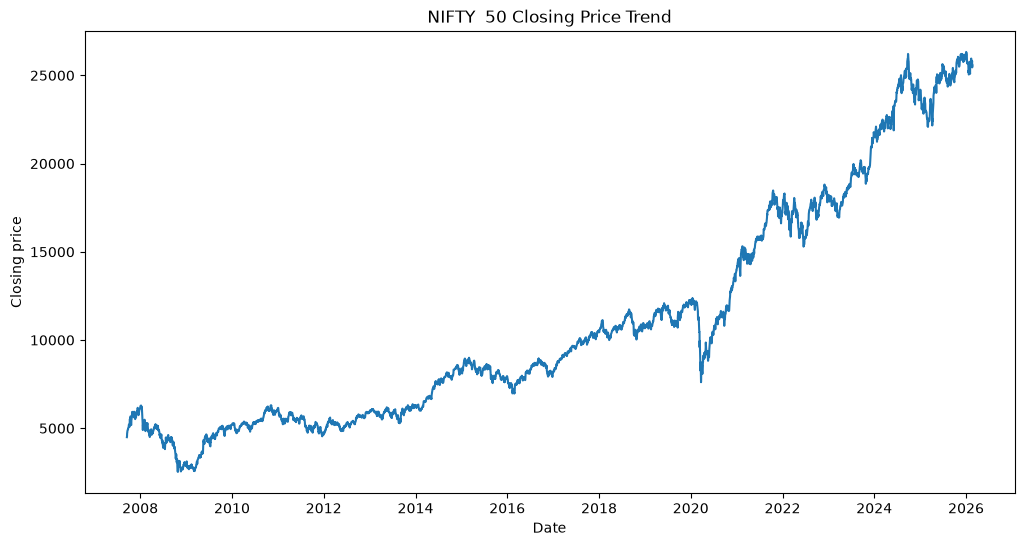

In [19]:
plt.figure(figsize=(12,6))
plt.plot(df["Date"],df["Close"])
plt.title("NIFTY  50 Closing Price Trend")
plt.xlabel("Date")
plt.ylabel("Closing price")
plt.show()

### Observation

The NIFTY 50 shows a strong long-term upward trend over the analyzed period. However, the trend was not continuous, with several periods of significant declines and subsequent recoveries. The most visible fluctuations occur around 2008–2009 and 2020, followed by strong recovery phases. The chart demonstrates the long-term growth of the index but does not by itself measure daily volatility.

### Trading Volume Over Time

Trading volume represents the number of units recorded as traded in the dataset on each trading day. The following visualization examines how trading activity changed over time.


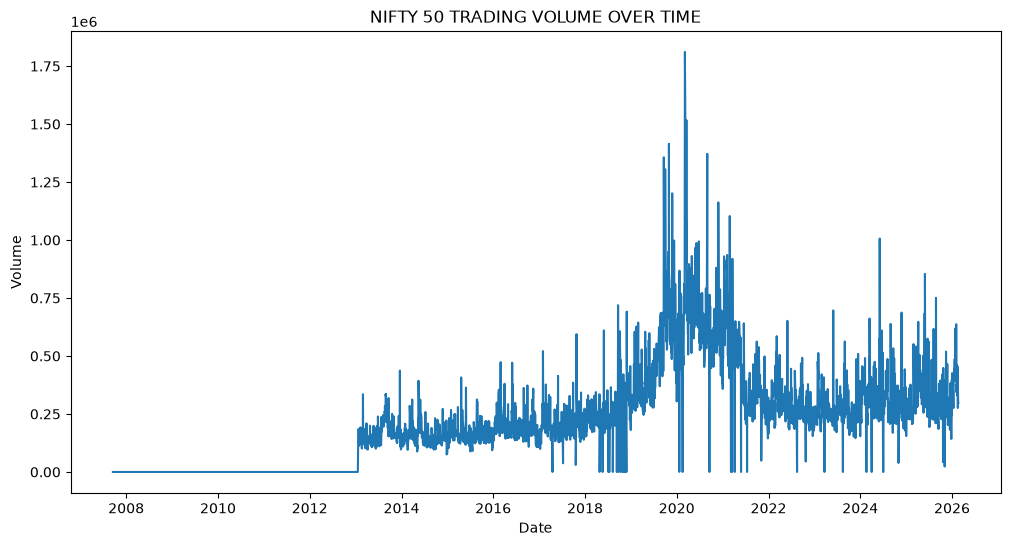

In [20]:
plt.figure(figsize=(12,6))
plt.plot(df["Date"],df["Volume"])
plt.title("NIFTY 50 TRADING VOLUME OVER TIME")
plt.xlabel("Date")
plt.ylabel("Volume")
plt.show()

### Observation

The trading volume series shows substantial variation over the analyzed period. Volume is recorded as zero during a large portion of the earlier observations and becomes more consistently populated in later years. Several large volume spikes are also visible, particularly around 2020 and subsequent periods. Since the dataset represents the NIFTY 50 index rather than an individual stock, the volume field should be interpreted cautiously. Therefore, volume will be treated as a supplementary variable rather than the primary basis for financial conclusions.

## 8. Daily Return Analysis

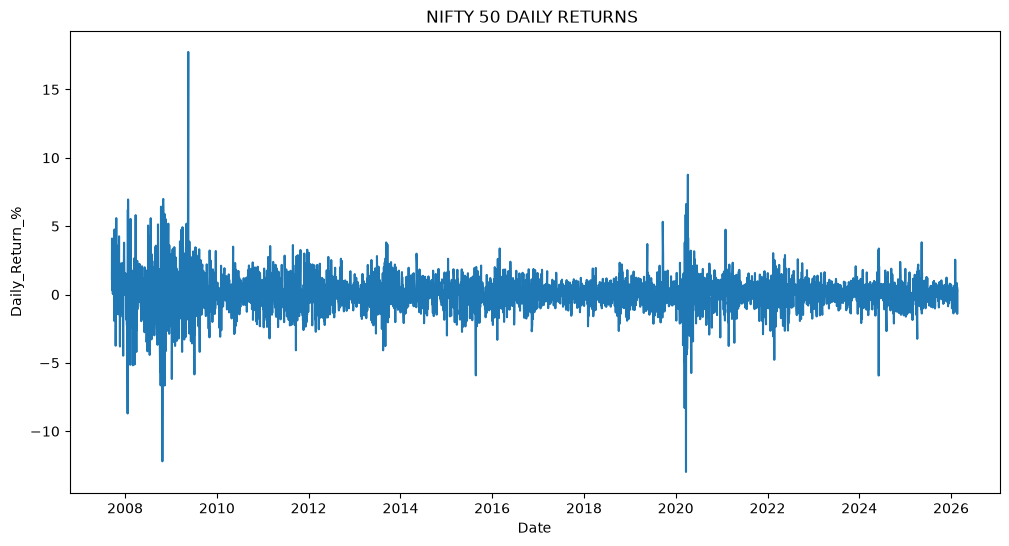

In [21]:
plt.figure(figsize=(12,6))
plt.plot(df["Date"],df["Daily_Return_%"])
plt.title("NIFTY 50 DAILY RETURNS ")
plt.xlabel("Date")
plt.ylabel("Daily_Return_%")
plt.show()

### Observation

Daily returns are concentrated around zero for most trading days, indicating relatively small day-to-day price movements under normal conditions. However, several extreme positive and negative returns are visible, particularly during periods of major market stress. The variation in the spread of returns over time also suggests that market volatility was not constant throughout the analyzed period, with certain periods exhibiting substantially larger daily movements.

In [22]:
max_return = df["Daily_Return_%"].max()
min_return = df["Daily_Return_%"].min()

print("Maximum Daily Return : ",max_return)

print("Minimum Daily Return : ",min_return)

Maximum Daily Return :  17.74406649131017
Minimum Daily Return :  -12.98046607047124


In [23]:
print(df.loc[df["Daily_Return_%"].idxmax(),["Date","Daily_Return_%"]])
print(df.loc[df["Daily_Return_%"].idxmin(),["Date","Daily_Return_%"]])

Date              2009-05-18 00:00:00
Daily_Return_%              17.744066
Name: 403, dtype: object
Date              2020-03-23 00:00:00
Daily_Return_%             -12.980466
Name: 3058, dtype: object


### Extreme Daily Return Observations

The highest daily return in the dataset was 17.7441% on 18 May 2009. The lowest daily return was -12.9805% on 23 March 2020. These observations represent the most extreme positive and negative one-day movements in the analyzed NIFTY 50 data. The dates and returns are directly identified from the dataset; the underlying causes of these movements are not inferred from the dataset alone.

### Return Distribution Analysis

A histogram is used to examine the distribution of daily returns and understand how frequently different ranges of returns occur.


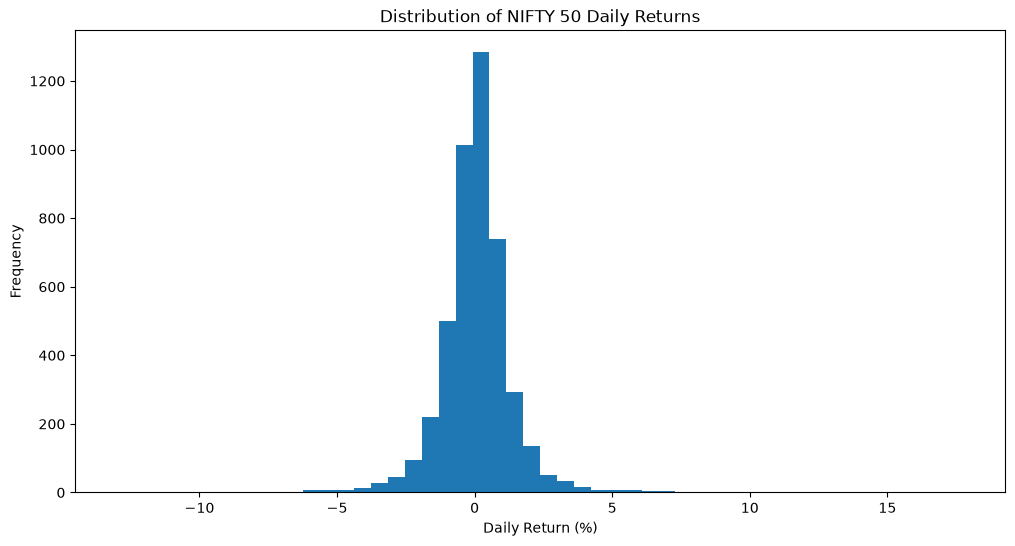

In [24]:
plt.figure(figsize =(12,6))
plt.hist(df["Daily_Return_%"].dropna(),bins = 50)

plt.title("Distribution of NIFTY 50 Daily Returns")
plt.xlabel("Daily Return (%)")
plt.ylabel("Frequency")

plt.show()

### Observation

The daily return distribution is strongly concentrated around zero, indicating that most trading days experienced relatively small price changes. The distribution also shows noticeable tails on both the positive and negative sides, reflecting the presence of occasional extreme daily movements. Therefore, the return series does not appear to follow a simple, narrow symmetric distribution based on visual inspection alone, and the presence of extreme observations should be considered in further volatility analysis.

### Distribution Statistics

In [25]:
returns = df["Daily_Return_%"].dropna()

print("SKewness : ", returns.skew())
print("Kurtosis : ", returns.kurt())

SKewness :  0.05605835144439669
Kurtosis :  16.067178626140414


### Extreme Return Analysis & Large Moves

In [26]:
positive_moves = (returns > 2).sum()
negative_moves = (returns < -2).sum()

print("Positive moves  above +2 : ",positive_moves)
print("Negative  moves  below -2 : ",negative_moves)

Positive moves  above +2 :  193
Negative  moves  below -2 :  194


In [27]:
positive_avg = returns[returns > 2].mean()
negative_avg = returns[returns < -2].mean()

print("Average big positive return:", positive_avg)
print("Average big negative return:", negative_avg)

Average big positive return: 3.2126277328364883
Average big negative return: -3.2302407601581886


In [28]:
positive_days = (returns > 0).sum()
negative_days = (returns < 0).sum()
zero_days = (returns == 0).sum()

print("Positive days:", positive_days)
print("Negative days:", negative_days)
print("Zero-return days:", zero_days)

Positive days: 2399
Negative days: 2118
Zero-return days: 4


In [29]:
positive_avg = returns[returns > 0].mean()
negative_avg = returns[returns < 0].mean()

print("Average positive-day return:", positive_avg)
print("Average negative-day return:", negative_avg)

Average positive-day return: 0.8542562690429927
Average negative-day return: -0.8674069309224957


In [30]:
positive_contribution = returns[returns > 0].sum()
negative_contribution = returns[returns < 0].sum()

print("Total positive returns:", positive_contribution)
print("Total negative returns:", negative_contribution)
print("Net return contribution:", positive_contribution + negative_contribution)

Total positive returns: 2049.3607894341394
Total negative returns: -1837.1678796938459
Net return contribution: 212.19290974029354


## 9. Cumulative Return

In [31]:
cumulative_return = (1 + returns / 100).prod() - 1

print("Cumulative return:", cumulative_return * 100, "%")

Cumulative return: 468.92640262516744 %


In [32]:
calculated_returns = df["Close"].pct_change() * 100

In [33]:
difference = calculated_returns - df["Daily_Return_%"]

print(difference.abs().max())

1.7763568394002505e-15


### Return Calculation Validation

The dataset-provided `Daily_Return_%` values were independently recalculated using the percentage change in the `Close` price. The maximum absolute difference between the calculated and provided returns was approximately 1.78 × 10⁻¹⁵, which is effectively zero and attributable to floating-point precision. This confirms that the provided daily return series is consistent with the closing-price data.

### ₹100 Hypothetical Growth Analysis

In [34]:
df["Investment_Value"] = 100 * (1 + calculated_returns / 100).cumprod()

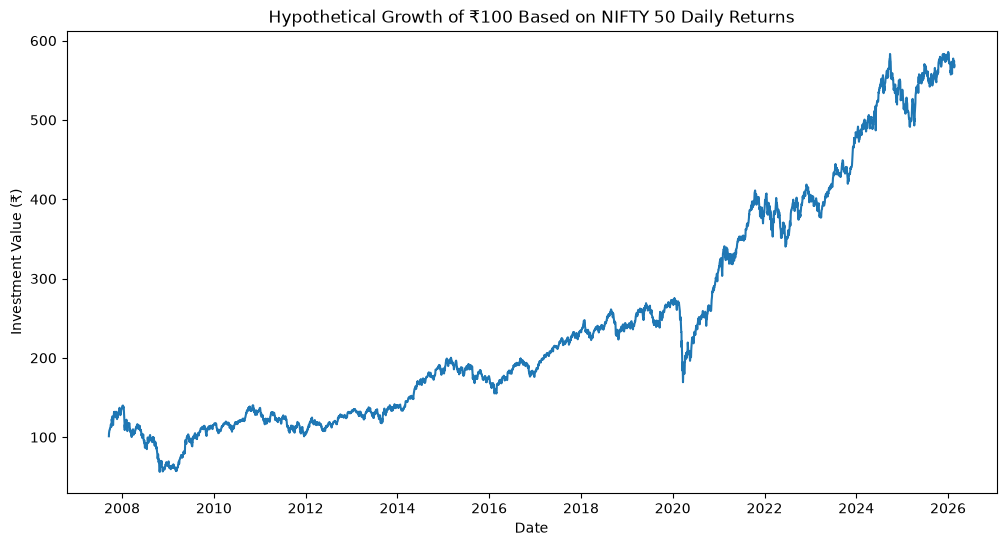

In [35]:
plt.figure(figsize=(12, 6))

plt.plot(df["Date"], df["Investment_Value"])

plt.title("Hypothetical Growth of ₹100 Based on NIFTY 50 Daily Returns")
plt.xlabel("Date")
plt.ylabel("Investment Value (₹)")

plt.show()

### Observation

The hypothetical ₹100 investment shows substantial long-term growth when the daily NIFTY 50 returns are compounded over the analyzed period. However, the growth path is not smooth. Significant drawdowns are visible around major market downturns, followed by recovery periods. This illustrates the effect of compounding over a long investment horizon while also demonstrating that long-term growth can involve substantial short-term declines.

Note: This represents a theoretical calculation based on daily index price returns and does not account for dividends, taxes, transaction costs, or other real-world investment factors.


## 10. Moving Average Analysis

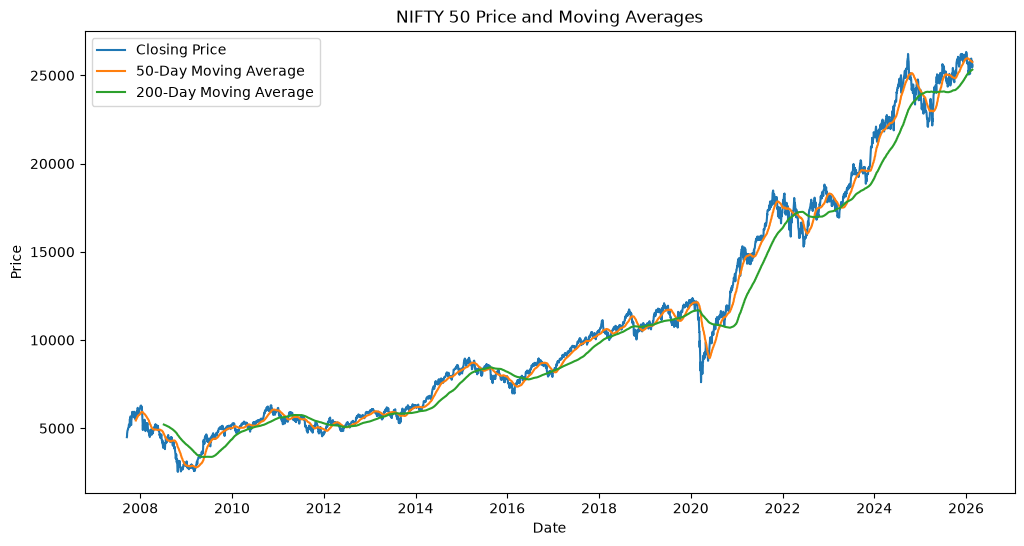

In [36]:
plt.figure(figsize=(12, 6))

plt.plot(df["Date"], df["Close"], label="Closing Price")
plt.plot(df["Date"], df["MA_50"], label="50-Day Moving Average")
plt.plot(df["Date"], df["MA_200"], label="200-Day Moving Average")

plt.title("NIFTY 50 Price and Moving Averages")
plt.xlabel("Date")
plt.ylabel("Price")

plt.legend()
plt.show()

### MA50 vs MA200 Relationship Analysis

In [37]:
valid_ma = df.dropna(subset=["MA_50", "MA_200"])

ma50_above = (valid_ma["MA_50"] > valid_ma["MA_200"]).sum()

percentage = (ma50_above / len(valid_ma)) * 100

print("Valid MA comparison days:", len(valid_ma))
print("MA 50 above MA 200:", ma50_above)
print("Percentage:", percentage)

Valid MA comparison days: 4323
MA 50 above MA 200: 3062
Percentage: 70.83044182280823


In [38]:
ma_signal = valid_ma["MA_50"] > valid_ma["MA_200"]

changes = ma_signal != ma_signal.shift()

print("Number of MA trend changes:", changes.sum())

Number of MA trend changes: 24


In [39]:
crossover_dates = valid_ma.loc[changes, ["Date", "MA_50", "MA_200"]]

print(crossover_dates)

crossover_dates["Signal"] = crossover_dates.apply(
    lambda row: "MA50 Above" if row["MA_50"] > row["MA_200"] else "MA50 Below",
    axis=1
)

print(crossover_dates)

           Date         MA_50        MA_200
200  2008-07-07   4696.748003   5210.716744
410  2009-05-27   3407.933984   3379.128486
852  2011-03-07   5640.707002   5649.698252
1099 2012-03-14   5193.431982   5177.483748
1165 2012-06-20   5068.921006   5072.077502
1192 2012-07-27   5105.881992   5101.794502
1442 2013-08-06   5848.036982   5850.075745
1500 2013-11-01   5862.612031   5857.840002
1888 2015-06-15   8338.330010   8340.605522
2123 2016-05-31   7795.502979   7788.497498
2267 2016-12-30   8248.710986   8250.035254
2301 2017-02-17   8394.841963   8392.669746
2731 2018-11-16  10750.360000  10754.273755
2811 2019-03-15  10887.535996  10886.238252
2930 2019-09-13  11204.601016  11216.472769
2967 2019-11-11  11365.361992  11354.144766
3056 2020-03-19  11555.963027  11592.763267
3161 2020-08-21  10831.461074  10831.131030
3570 2022-04-18  17157.349063  17164.687236
3670 2022-09-09  16982.004941  16966.627993
3813 2023-04-10  17512.539023  17522.765737
3849 2023-06-01  17861.443125  1

In [40]:
latest = valid_ma.iloc[-1]

print("Latest Date:", latest["Date"])
print("MA 50:", latest["MA_50"])
print("MA 200:", latest["MA_200"])

if latest["MA_50"] > latest["MA_200"]:
    print("Current relationship: MA50 is ABOVE MA200")
else:
    print("Current relationship: MA50 is BELOW MA200")

Latest Date: 2026-02-20 00:00:00
MA 50: 25760.2261328125
MA 200: 25322.43859375
Current relationship: MA50 is ABOVE MA200


### Moving Average Observation

Among the 4,323 observations where both moving averages were available, the 50-day moving average was above the 200-day moving average on 3,062 days, representing approximately 70.83% of the valid observations. The relationship changed 24 times during the analyzed period. At the final available observation on 20 February 2026, the 50-day moving average was 25,760.23, above the 200-day moving average of 25,322.44.

These moving-average relationships are used as descriptive trend indicators and should not be interpreted as standalone trading signals.


## 11. Volatility Analysis

### Rolling Volatility Analysis

In [41]:
rolling_volatility = returns.rolling(window=30).std()

print(rolling_volatility.head())

2   NaN
3   NaN
4   NaN
5   NaN
6   NaN
Name: Daily_Return_%, dtype: float64


In [42]:
print(rolling_volatility.dropna().head())

31    2.227380
32    2.227955
33    2.158980
34    2.158574
35    2.184045
Name: Daily_Return_%, dtype: float64


In [43]:
print("Average 30-day volatility:", rolling_volatility.mean())
print("Maximum 30-day volatility:", rolling_volatility.max())

Average 30-day volatility: 1.1027887945952781
Maximum 30-day volatility: 4.840942691965477


In [44]:
max_volatility_date = rolling_volatility.idxmax()

print("Maximum volatility:", rolling_volatility.max())
print("Date:", df.loc[max_volatility_date, "Date"])

Maximum volatility: 4.840942691965477
Date: 2008-11-24 00:00:00


### Volatility Observation

The average 30-day rolling volatility of NIFTY 50 daily returns was approximately 1.10%. The maximum observed 30-day rolling volatility was approximately 4.84%, occurring on 24 November 2008. This indicates that the period surrounding late November 2008 experienced substantially greater day-to-day return variability than the long-term average.

### 30-Day Rolling Volatility

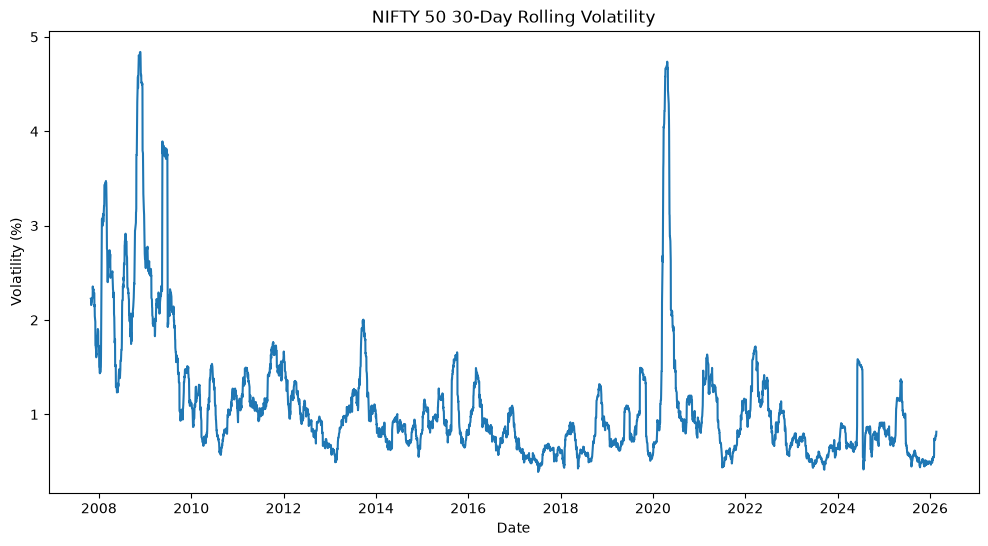

In [45]:
plt.figure(figsize=(12, 6))

plt.plot(df["Date"].iloc[1:], rolling_volatility)

plt.title("NIFTY 50 30-Day Rolling Volatility")
plt.xlabel("Date")
plt.ylabel("Volatility (%)")

plt.show()

### Volatility Observation

The 30-day rolling volatility shows that NIFTY 50 volatility varied considerably over time rather than remaining constant. The highest rolling volatility of approximately 4.84% occurred on 24 November 2008. Another major volatility spike is visible around 2020, coinciding with the period containing the dataset's lowest daily return of -12.98% on 23 March 2020. The volatility series also shows periods of relatively lower and more stable variability between major turbulent periods, indicating that return volatility tends to cluster during periods of heightened market uncertainty.

### Yearly Volatility Analysis

In [46]:
df["Rolling_Volatility"] = rolling_volatility

In [47]:
yearly_volatility = df.groupby(df["Date"].dt.year)["Rolling_Volatility"].mean()

print(yearly_volatility)

Date
2007    2.024431
2008    2.608346
2009    2.117138
2010    1.009731
2011    1.286525
2012    1.008542
2013    1.080531
2014    0.799038
2015    1.007659
2016    0.930311
2017    0.584231
2018    0.755770
2019    0.857315
2020    1.571958
2021    0.927500
2022    1.062706
2023    0.606784
2024    0.845630
2025    0.718315
2026    0.608242
Name: Rolling_Volatility, dtype: float64


In [48]:
top_5_volatility = yearly_volatility.sort_values(ascending=False).head(5)

print(top_5_volatility)

Date
2008    2.608346
2009    2.117138
2007    2.024431
2020    1.571958
2011    1.286525
Name: Rolling_Volatility, dtype: float64


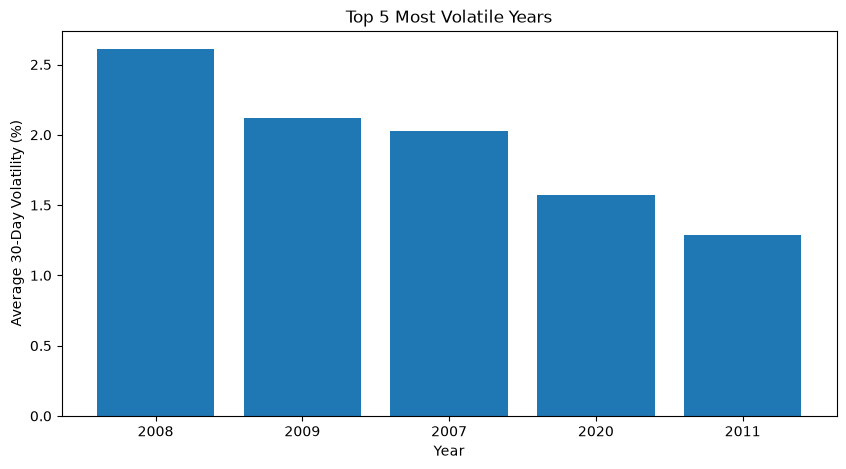

In [49]:
plt.figure(figsize=(10, 5))

plt.bar(top_5_volatility.index.astype(str), top_5_volatility.values)

plt.title("Top 5 Most Volatile Years")
plt.xlabel("Year")
plt.ylabel("Average 30-Day Volatility (%)")

plt.show()

### Volatility Findings

The highest average 30-day rolling volatility was observed in 2008 at approximately 2.61%, followed by 2009 at 2.12%. The year 2020 also recorded elevated volatility at approximately 1.57%. This indicates that the NIFTY 50 experienced periods of concentrated market turbulence rather than maintaining a constant level of volatility throughout the dataset.

Note: 2007 (begins 17 September) and 2026 (ends 20 February) are partial years in the dataset and should therefore be interpreted with caution when making full-year comparisons.


# Key Findings

## 1. Overall NIFTY 50 Price Trend

The NIFTY 50 closing price showed a strong long-term upward trend over the analyzed period from September 2007 to February 2026. Although the index experienced several major declines and periods of uncertainty, the overall closing price increased substantially over the period.

## 2. Daily Return Behavior

The average daily return was close to zero, while both positive and negative daily movements occurred frequently. There were 2,399 positive-return days and 2,118 negative-return days, with 4 days showing approximately zero return.

The maximum daily return was 17.74% on 18 May 2009, while the minimum daily return was -12.98% on 23 March 2020. These extreme observations demonstrate that large market movements can occur during periods of significant market stress or rapid recovery.

## 3. Distribution of Returns

The skewness of daily returns was approximately 0.056, indicating that the return distribution was close to symmetric overall. However, the kurtosis was approximately 16.07, indicating heavy tails and the presence of extreme observations compared with a normal distribution.

## 4. Large Daily Movements

There were 193 days with returns above +2% and 194 days with returns below -2%. The average return among large positive movements was approximately +3.21%, while the average return among large negative movements was approximately -3.23%.

## 5. Moving Average Trend

The 50-day moving average was above the 200-day moving average on 3,062 of 4,323 valid comparison days, representing approximately 70.83% of the valid observations.

The relationship between the two moving averages changed 24 times during the analyzed period. At the final observation on 20 February 2026, the 50-day moving average was approximately 25,760.23, compared with approximately 25,322.44 for the 200-day moving average.

These moving-average relationships are used as descriptive trend indicators and should not be interpreted as standalone trading signals.

## 6. Volatility

The average 30-day rolling volatility was approximately 1.10%. The maximum observed 30-day rolling volatility was approximately 4.84% on 24 November 2008.

The highest average annual rolling volatility was observed in 2008 at approximately 2.61%, followed by 2009 at approximately 2.12%. The year 2020 also showed elevated volatility at approximately 1.57%.

The volatility analysis indicates that market variability was not constant over time and that periods of higher volatility were concentrated around major market disturbances.

## 7. Data Quality

The dataset initially contained one non-data row containing ticker information and several missing values associated with calculated fields such as daily returns and moving averages. The non-data row was removed, data types were converted appropriately, and basic validation checks were performed.

No observations were found where High was lower than Low, Low was greater than Open, Low was greater than Close, or Volume was negative.

The compounded cumulative return calculated from the daily NIFTY 50 returns over the analyzed period was approximately 468.93%. On a hypothetical basis, an initial value of ₹100 would have grown to approximately ₹568.93 when the daily returns are compounded. This calculation is based solely on the index's daily price returns and does not account for dividends, transaction costs, taxes, or other investment-related factors.


## 13. Conclusion

This Week 1 Exploratory Data Analysis (EDA) successfully cleaned, structured, validated, and analyzed historical NIFTY 50 index data spanning September 2007 to February 2026. Key quantitative insights demonstrate long-term index growth, heavy-tailed return distributions with periodic extreme daily events, persistent positive moving-average regimes (70.83% of valid trading days), and volatility clustering during market stress periods. The cleaned dataset and validated outputs provide a reliable, submission-ready baseline for Week 1.
